In [25]:
import tensorflow as tf
from keras import layers, models
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

from src.data.freihand import FreiHand

In [26]:
dataset = FreiHand()
dataset.validate()

train_idx, val_idx = dataset.train_validation_split(validation_fraction=0.1)

train_ds = dataset.tf_dataset(
    indices=train_idx,   # start lite!
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    flatten_keypoints=True
)

val_ds = dataset.tf_dataset(
    indices=val_idx,
    batch_size=32,
    image_size=(128, 128),
    flatten_keypoints=True
)

In [27]:
model = models.Sequential([
  layers.Input(shape=(128,128,3)),

  layers.Conv2D(32, (3,3), padding="same", activation="relu"),
  layers.BatchNormalization(),
  layers.Conv2D(32, (3,3), padding="same", activation="relu"),
  layers.MaxPooling2D(),

  layers.Conv2D(64, (3,3), padding="same", activation="relu"),
  layers.BatchNormalization(),
  layers.Conv2D(64, (3,3), padding="same", activation="relu"),
  layers.MaxPooling2D(),

  layers.Conv2D(128, (3,3), padding="same", activation="relu"),
  layers.MaxPooling2D(),

  layers.Flatten(),
  layers.Dense(128, activation="relu"),
  layers.Dropout(0.5),
  layers.Dense(42)
])

In [28]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [29]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"]
)

In [30]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
916/916 ━━━━━━━━━━━━━━━━━━━━ 265s 288ms/step - loss: 429.4075 - mae: 15.9396 - val_loss: 170.5810 - val_mae: 10.5127
Epoch 2/15
916/916 ━━━━━━━━━━━━━━━━━━━━ 260s 284ms/step - loss: 226.8169 - mae: 11.9693 - val_loss: 106.7215 - val_mae: 8.2082
Epoch 3/15
916/916 ━━━━━━━━━━━━━━━━━━━━ 268s 292ms/step - loss: 203.2670 - mae: 11.3035 - val_loss: 99.4021 - val_mae: 7.8536
Epoch 4/15
916/916 ━━━━━━━━━━━━━━━━━━━━ 290s 317ms/step - loss: 198.3112 - mae: 11.1677 - val_loss: 108.5950 - val_mae: 8.2899
Epoch 5/15
916/916 ━━━━━━━━━━━━━━━━━━━━ 286s 312ms/step - loss: 192.8383 - mae: 11.0095 - val_loss: 92.4747 - val_mae: 7.6295
Epoch 6/15
916/916 ━━━━━━━━━━━━━━━━━━━━ 270s 295ms/step - loss: 187.0747 - mae: 10.8368 - val_loss: 89.7737 - val_mae: 7.4427
Epoch 7/15
916/916 ━━━━━━━━━━━━━━━━━━━━ 262s 286ms/step - loss: 188.9824 - mae: 10.8840 - val_loss: 84.3961 - val_mae: 7.2314
Epoch 8/15
916/916 ━━━━━━━━━━━━━━━━━━━━ 261s 284ms/step - loss: 185.5160 - mae: 10.7883 - val_loss: 89.4150 - val_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


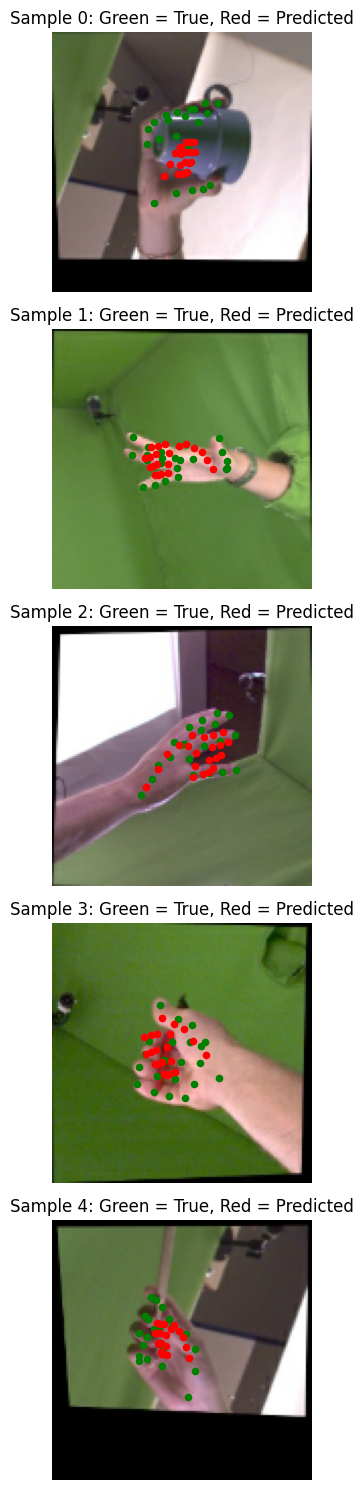

In [31]:
for images, keypoints in val_ds.take(1):
    break

preds = model.predict(images)

import matplotlib.pyplot as plt

num_samples = 5
img_h, img_w = 128, 128

plt.figure(figsize=(15, 3 * num_samples))

for i in range(num_samples):
    img = images[i].numpy()
    true_kp = keypoints[i].numpy().reshape(21, 2)
    pred_kp = preds[i].reshape(21, 2)

    plt.subplot(num_samples, 1, i + 1)
    plt.imshow(img)

    for x, y in true_kp:
        plt.scatter(x, y, c="green", s=20)

    for x, y in pred_kp:
        plt.scatter(x, y, c="red", s=20)

    plt.title(f"Sample {i}: Green = True, Red = Predicted")
    plt.axis("off")

plt.tight_layout()
plt.show()